In [1]:
import sys

import numpy as np
import pandas as pd
import re

import seaborn as sns
from IPython.display import Image
import matplotlib.pyplot as plt

In [2]:
np.set_printoptions(threshold=sys.maxsize)

In [3]:
# Load Parsed Logs
raw_parse = pd.read_csv("C:\\01. Monash University\\controlroom-xai-alarm-support-transformer\\log_anomaly_detection\\XAI_Anomaly_Detection_Transformer\\Spell_result\\out_structured.csv")
raw_parse.head(2)

,LineId,Date,Time,Pid,Level,Component,Content,Log Key,Message,ParameterList
0,1,81109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,1,Receiving block <*> src <*> dest <*>,"['blk_-1608999687919862906', '/10.250.19.102:5..."
1,2,81109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,2,BLOCK* NameSystem.allocateBlock <*> <*>,"['', '/mnt/hadoop/mapred/system/job_2008110920..."


In [4]:
raw_parse.info()

<class 'pandas.DataFrame'>
RangeIndex: 11174243 entries, 0 to 11174242
Data columns (total 10 columns):
 #   Column         Dtype
---  ------         -----
 0   LineId         int64
 1   Date           int64
 2   Time           int64
 3   Pid            int64
 4   Level          str  
 5   Component      str  
 6   Content        str  
 7   Log Key        int64
 8   Message        str  
 9   ParameterList  str  
dtypes: int64(5), str(5)
memory usage: 3.2 GB


# Data Understanding

# HDFS.log (Raw Logs)

## Date Range

In [5]:
raw_parse['Date'].value_counts()

Date
81111    5362080
81110    4932796
81109     879367
Name: count, dtype: int64

The datasets are from 09 - 11 November 2008.  
  
Time Span of **HDFS_v1 is 38.7 hours** (2-3 days)

## Time Range

In [6]:
raw_parse['Time'].value_counts()

Time
75622     5175
110439    5036
75635     5008
110430    4985
44322     4979
          ... 
65131        1
85828        1
100116       1
100126       1
100214       1
Name: count, Length: 85053, dtype: int64

In [7]:
raw_parse['Time'].value_counts().sort_index()

Time
0         109
1         215
2         242
3         155
4         194
         ... 
235955    131
235956    124
235957    132
235958    159
235959    105
Name: count, Length: 85053, dtype: int64

`24 hours: 60 minutes: 60 seconds` format.

In [8]:
time_format = raw_parse['Time']\
                .astype(str)\
                .str.zfill(6)

In [9]:
# Hour Distribution
time_format.str[:2]\
    .value_counts().sort_index()

Time
00     202260
01     461007
02     478236
03     486522
04     870899
05     495705
06     673954
07     753283
08     677609
09     623956
10    1278223
11     690664
12     340103
13      93782
14     255394
15     181779
16      24466
17      27506
18      27078
19      26716
20     213299
21    1182880
22     726584
23     382338
Name: count, dtype: int64

In [10]:
# Minute Distribution
time_format.str[2:4]\
    .value_counts().sort_index()

Time
00    160218
01    401542
02    183445
03    166901
04    298576
05    292625
06    325290
07    167256
08    173865
09    202858
10    158179
11    145735
12    152656
13    146769
14    144140
15    141035
16    138013
17    137006
18    135177
19    136739
20    132879
21    135813
22    134813
23    135912
24    137542
25    137339
26    130620
27    133474
28    132076
29    131802
30    369066
31    339557
32    206746
33    185412
34    178503
35    221331
36    224970
37    196581
38    171830
39    150225
40    151795
41    145356
42    148583
43    351764
44    147888
45    163727
46    194571
47    228059
48    181797
49    147928
50    142721
51    140440
52    241173
53    155011
54    193988
55    161467
56    251833
57    153638
58    184835
59    293153
Name: count, dtype: int64

In [11]:
# Second Distribution
time_format.str[4:]\
    .value_counts().sort_index()

Time
00    174908
01    174397
02    168864
03    170814
04    172825
05    175734
06    179998
07    178288
08    179755
09    182341
10    182631
11    184183
12    187784
13    185865
14    187730
15    190592
16    191921
17    191933
18    191908
19    192041
20    189858
21    190315
22    187910
23    189649
24    186876
25    194009
26    195508
27    193308
28    194730
29    196097
30    192200
31    193499
32    189030
33    194030
34    190105
35    194522
36    192828
37    193337
38    197827
39    195496
40    191241
41    190988
42    188633
43    191742
44    191532
45    188516
46    189372
47    188931
48    189901
49    185008
50    186043
51    178807
52    173861
53    176931
54    177443
55    178068
56    179497
57    178231
58    177811
59    176041
Name: count, dtype: int64

## PID

In [12]:
raw_parse['Pid'].value_counts()

Pid
19       1288017
28        539753
27        442840
26        441381
30        437962
          ...   
27883          1
27885          1
27887          1
27889          1
27893          1
Name: count, Length: 27799, dtype: int64

**Process ID** : Number assigned by the operating system to identify which running process generated this log line.

## Level

In [13]:
raw_parse['Level'].value_counts()

Level
INFO    10811450
WARN      362793
Name: count, dtype: int64

In [14]:
raw_parse[['Log Key', 'Level']].value_counts().sort_index(level='Log Key', ascending=True)

Log Key  Level
1        INFO     1723232
2        INFO      575061
3        INFO     1706728
4        INFO     1713611
5        INFO     1719741
6        INFO      435697
7        INFO        7002
8        INFO        7002
9        INFO      120036
10       INFO        3300
11       INFO          44
12       INFO          82
13       INFO     1402047
14       INFO        1464
15       INFO          75
16       INFO           3
17       WARN         975
18       INFO          59
19       INFO          65
20       INFO           2
21       INFO           9
22       WARN           9
23       INFO     1396174
24       WARN        5545
25       WARN      356207
26       INFO           2
27       INFO           5
28       INFO           4
29       WARN          47
30       INFO           5
31       WARN          10
Name: count, dtype: int64

[Log level hierarchy explained](https://www.xurrent.com/blog/log-levels#:~:text=Each%20of%20these%20logs%20carries,still%20capture%20ERROR%20and%20FATAL.)
   
Every logging framework follows a **severity hierarchy**. At the top is FATAL, and at the bottom is TRACE.   

The higher you go, the more urgent the message. The lower you go, the more verbose and diagnostic the output.  
  
This order is what allows **log filtering to work correctly**.   
  
When your logger is set to **WARN, it will suppress INFO and DEBUG, but still capture ERROR and FATAL**.

*  FATAL : When Your System Cannot Recover
*  ERROR : Something Broke but the System Is Still Running
*  WARN  : When Something Looks Off but Is Still Working
*  INFO  : Operational Milestones and Routine Events
*  DEBUG : Diagnostic Logs for Troubleshooting

In [15]:
raw_parse[raw_parse['Level'] == 'WARN'][['Log Key', 'Level', 'Message']].value_counts().sort_index(level='Log Key', ascending=True)

Log Key  Level  Message                                                                                           
17       WARN   BLOCK* NameSystem.addStoredBlock Redundant addStoredBlock request received for <*> on <*> size <*>       975
22       WARN   <*>Failed to transfer <*> to <*> got java.io.IOException Connection reset by peer                          9
24       WARN   Unexpected error trying to delete block <*>. BlockInfo not found in volumeMap.                          5545
25       WARN   <*>Got exception while serving <*> to <*>                                                             356207
29       WARN   PendingReplicationMonitor timed out block <*>                                                             47
31       WARN   Adding an already existing block <*>                                                                      10
Name: count, dtype: int64

In [16]:
raw_parse[raw_parse['Level'] != 'WARN'][['Log Key', 'Level', 'Message']].value_counts().sort_index(level='Log Key', ascending=True)

Log Key  Level  Message                                                                                                                                                                      
1        INFO   Receiving block <*> src <*> dest <*>                                                                                                                                             1723232
2        INFO   BLOCK* NameSystem.allocateBlock <*> <*>                                                                                                                                           575061
3        INFO   PacketResponder <*> for block <*> <*>                                                                                                                                            1706728
4        INFO   Received block <*> of size <*> <*>                                                                                                                                               1713611
5     

## Component

In [17]:
raw_parse['Component'].value_counts()

Component
dfs.FSNamesystem                                          3698957
dfs.DataNode$PacketResponder                              3413295
dfs.DataNode$DataXceiver                                  2518656
dfs.FSDataset                                             1407597
dfs.DataBlockScanner                                       120046
dfs.DataNode                                                 7002
dfs.DataNode$DataTransfer                                    6946
dfs.DataNode$BlockReceiver                                   1697
dfs.PendingReplicationBlocks$PendingReplicationMonitor         47
Name: count, dtype: int64

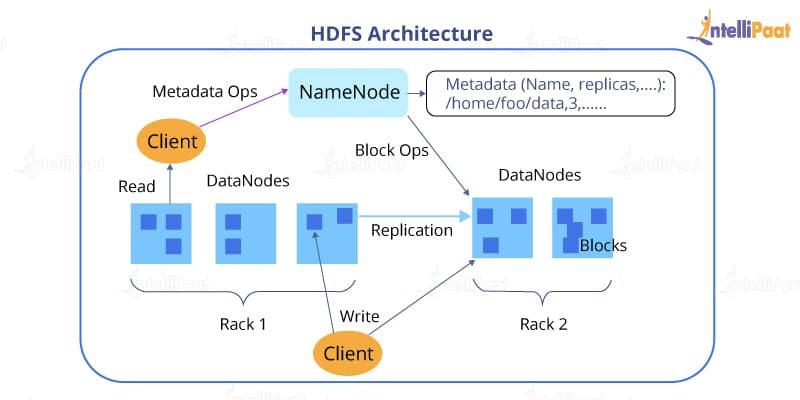

*  `dfs.FSNamesystem`: 657  
   Core component of the NameNode that manages the HDFS filesystem namespace (hierarchical directory structure), maintains metadata (file attributes and permissions), and tracks the mapping of data blocks to DataNodes.    
     
*  `dfs.DataNode$PacketResponder` : 603  
   Handles acknowledgements for data packets during block write operations. When data is written to HDFS, packets are sent through a pipeline of `DataNodes` and `PacketResponder` sends acknowledgement responses back through the pipeline.  
      
*  `dfs.DataNode$DataXceiver` : 454   
    Manages **data transfer operations** between clients and `DataNodes` or between `DataNodes` themselves. It handles block reads, writes, and replication data transfers.  

*  `dfs.FSDataset`: 263   
    Manages block storage on disk inside a `DataNode`, including storing block files, maintaining block metadata, and interacting with local storage.  

*  `dfs.DataBlockScanner`: 20   
   Background process that periodically scans stored blocks to verify data integrity using checksums and detect corrupted blocks.  

*  `dfs.DataNode `: 1    
   Main DataNode service component responsible for communicating with the `NameNode`, sending heartbeats and block reports, and coordinating storage and retrieval of HDFS data blocks.

## Content

In [18]:
raw_parse['Content'].value_counts()

Content
10.250.14.224:50010:Got exception while serving blk_-1347702416509823842 to /10.250.14.224:           15
10.251.215.192:50010:Got exception while serving blk_8512415457710305414 to /10.251.215.192:          13
10.251.30.179:50010:Got exception while serving blk_2356980171746022239 to /10.251.30.179:            13
Deleting block blk_-1608999687919862906 file /mnt/hadoop/dfs/data/current/blk_-1608999687919862906    10
10.251.194.213:50010:Got exception while serving blk_3584987098972940224 to /10.251.194.213:          10
                                                                                                      ..
Verification succeeded for blk_-6171368032583208892                                                    1
Verification succeeded for blk_6195025276114316035                                                     1
Verification succeeded for blk_-3339773404714332088                                                    1
Verification succeeded for blk_1037231945509285

**Log Parsing (`detection_model.py`)**
  
The `parse()` function extracts structured information from raw HDFS log entries using regular expressions.

```python
def parse():
    ...
    regex = [
        r'blk_(|-)[0-9]+',                         # Block ID
        r'(/|)([0-9]+\.){3}[0-9]+(:[0-9]+|)(:|)',   # IP address
        r'(?<=[^A-Za-z0-9])(\-?\+?\d+)(?=[^A-Za-z0-9])|[0-9]+$',  # Numbers
    ]
    ...
```

These patterns identify dynamic values (e.g., block IDs, IP addresses, and numbers) and replace them with the wildcard symbol `<*>`.

---

### Log Structure

Each `Content` field is parsed into three components:

- **Log Key** : identifier for the log template  
- **Message** : normalized log message with parameters replaced by `$<*>$`  
- **ParameterList** : extracted variable values

---

### Example

Raw log content:

```
PacketResponder 1 for block blk_38865049064139660 terminating
```

Parsed result:

- **Log Key:** `1`
- **Message:** `PacketResponder <*> for block <*> terminating`
- **ParameterList:** `['1', 'blk_38865049064139660']`

Then the massages will be categorize by `LCSsearch` methodes in Spell algorithm and produce `out_templates.csv`

In [19]:
# Load Parsed Logs
raw_templates = pd.read_csv("C:\\01. Monash University\\controlroom-xai-alarm-support-transformer\\log_anomaly_detection\\XAI_Anomaly_Detection_Transformer\\Spell_result\\out_templates.csv")

raw_templates.sort_values('Log Key')

,Log Key,Message,Occurrences
0,1,Receiving block <*> src <*> dest <*>,1723232
6,2,BLOCK* NameSystem.allocateBlock <*> <*>,575061
3,3,PacketResponder <*> for block <*> <*>,1706728
2,4,Received block <*> of size <*> <*>,1713611
1,5,BLOCK* NameSystem.addStoredBlock blockMap upda...,1719741
7,6,<*> block <*> to <*>,435697
10,7,<*> Starting thread to transfer block <*> to <...,7002
11,8,BLOCK* ask <*> to replicate <*> to datanode s ...,7002
9,9,Verification succeeded for <*>,120036
13,10,writeBlock <*> received exception <*>,3300


# HDFS Train

In [20]:
hdfs_train = pd.read_csv(
    "C:\\01. Monash University\\controlroom-xai-alarm-support-transformer\\log_anomaly_detection\\XAI_Anomaly_Detection_Transformer\\Dataset\\HDFS\\hdfs_train",
    header=None,
    names=["sequence"]
)

hdfs_train.head(2)

,sequence
0,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...
1,22 5 5 5 11 9 11 9 11 9 26 26 26


In [21]:
hdfs_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4854 entries, 0 to 4853
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sequence  4854 non-null   str  
dtypes: str(1)
memory usage: 280.3 KB


## Event Occurences

In [22]:
all_event_ids = (
    hdfs_train["sequence"]
    .str.split()          
    .explode()            # flatten into rows
    .astype(int) 
)

all_event_ids.info()

<class 'pandas.Series'>
Index: 95103 entries, 0 to 4853
Series name: sequence
Non-Null Count  Dtype
--------------  -----
95103 non-null  int64
dtypes: int64(1)
memory usage: 1.5 MB


In [24]:
np.unique(all_event_ids)

array([ 2,  3,  4,  5,  6,  9, 11, 16, 18, 21, 22, 23, 25, 26])

In [25]:
event_counts = all_event_ids.value_counts().sort_index()

event_counts

sequence
2      1070
3      3734
4      3211
5     14592
6        29
9     14562
11    14562
16       29
18       29
21    11905
22     4855
23    11877
25       29
26    14619
Name: count, dtype: int64

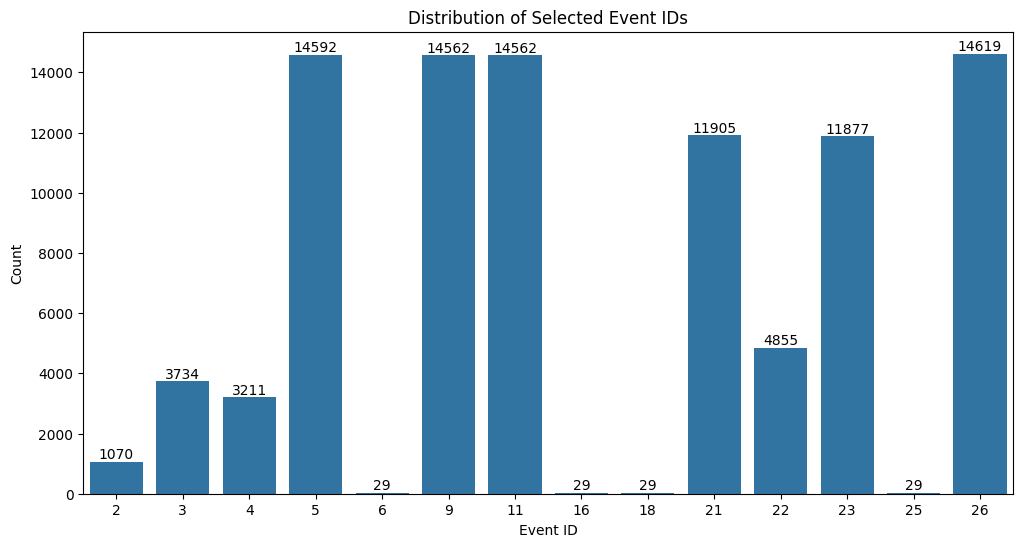

In [26]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=event_counts.index, y=event_counts.values)

for i, v in enumerate(event_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Distribution of Selected Event IDs")
plt.xlabel("Event ID")
plt.ylabel("Count")

plt.show()

## Sequence Length

In [27]:
seq_len = hdfs_train["sequence"].str.split().apply(len)

seq_len.value_counts()

sequence
19    2563
13     833
25     280
22     241
23     184
20     178
31     129
24     108
28      97
26      59
14      44
21      40
30      15
27      14
37      14
35      13
32      13
29      11
36       7
38       7
42       2
15       1
33       1
Name: count, dtype: int64

In [30]:
hdfs_train.value_counts()

sequence                                                       
5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21                 802
5 5 22 5 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21                 404
5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21                 392
5 5 5 22 11 9 11 9 11 9 26 26 26                                   253
22 5 5 5 26 26 26 11 9 11 9 11 9 23 23 23 21 21 21                 208
                                                                  ... 
5 5 5 22 11 9 9 11 9 11 26 26 26 4 4 3 2 23 23 23 21 21 21           1
5 5 5 22 11 9 11 9 26 26 26 11 9 2 4 3 23 23 23 21 21 21             1
5 5 22 5 26 26 11 9 11 9 26 11 9 23 23 23 21 21 21                   1
5 22 5 5 11 9 26 11 9 11 9 26 26 3 3 4 23 23 23 21 21 21             1
5 22 5 5 11 11 9 9 11 9 26 26 26 3 4 3 3 4 3 23 23 23 21 21 21       1
Name: count, Length: 839, dtype: int64

In [42]:
hdfs_train['sequence'].nunique()

839

# Test Normal

In [43]:
test_normal = pd.read_csv(
    "C:\\01. Monash University\\controlroom-xai-alarm-support-transformer\\log_anomaly_detection\\XAI_Anomaly_Detection_Transformer\\Dataset\\HDFS\\hdfs_test_normal",
    header=None,
    names=["sequence"]
)

test_normal.head(2)

,sequence
0,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...
1,5 5 22 5 11 9 11 9 11 9 26 26 26


In [44]:
test_normal.info()

<class 'pandas.DataFrame'>
RangeIndex: 553366 entries, 0 to 553365
Data columns (total 1 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   sequence  553366 non-null  str  
dtypes: str(1)
memory usage: 31.1 MB


## Event Occurences

In [45]:
all_event_normal = (
    test_normal["sequence"]
    .str.split()          
    .explode()            # flatten into rows
    .astype(int) 
)

all_event_normal.info()

<class 'pandas.Series'>
Index: 10792214 entries, 0 to 553365
Series name: sequence
Non-Null Count     Dtype
--------------     -----
10792214 non-null  int64
dtypes: int64(1)
memory usage: 164.7 MB


In [51]:
event_counts_normal = all_event_normal.value_counts().sort_index()

event_counts_normal

sequence
2      115836
3      413148
4      344733
5     1662687
6        2588
9     1660098
11    1660098
16       2513
18       2514
20        222
21    1354660
22     553366
23    1352365
25       2514
26    1664857
27          3
28         12
Name: count, dtype: int64

In [46]:
np.unique(all_event_normal)

array([ 2,  3,  4,  5,  6,  9, 11, 16, 18, 20, 21, 22, 23, 25, 26, 27, 28])

In [53]:
unseen_events = np.setdiff1d(np.unique(all_event_normal), np.unique(all_event_ids))

print("Unseen Event IDs in Test Set:", unseen_events)

Unseen Event IDs in Test Set: [20 27 28]


Analysis of the parsed `EventID` sequences shows that `hdfs_test_normal` contains `EventIDs 20, 27, and 28`, which do not appear in the training set.  
   
These **do not constitute index-out-of-range errors**, since they remain within the configured vocabulary range (`VOCAB_SIZE = 29`).   
     
Instead, they represent unseen but valid events at test time. This mismatch between train and test distributions may **reduce model reliability and contribute to false positives during anomaly detection**.

In [69]:
total_unseen_events = all_event_normal[all_event_normal.isin(unseen_events)].sum()

print(f"Total Unseen Events in Test Set: {total_unseen_events}")
print(f"Percentage of Unseen Events in Test Set: {total_unseen_events / len(test_normal) * 100:.2f}%")

Total Unseen Events in Test Set: 4857
Percentage of Unseen Events in Test Set: 0.88%


## Sequence Length

In [82]:
test_normal.value_counts()

sequence                                                                             
5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21                                       93992
5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21                                       50336
5 5 22 5 11 9 11 9 11 9 26 26 26 23 23 23 21 21 21                                       47522
5 5 5 22 11 9 11 9 11 9 26 26 26                                                         30960
22 5 5 5 26 26 26 11 9 11 9 11 9 23 23 23 21 21 21                                       21267
                                                                                         ...  
22 5 5 5 26 26 26 11 9 11 9 11 9 3 4 3 3 4 3 2 3 4 3 3 4 23 23 23 21 21 21                   1
5 22 5 5 11 9 11 9 26 26 11 9 26 4 4 4 4 4 3 4 4 4 4 4 4 4 4 4 4 2 23 23 23 21 21 21         1
22 5 5 5 9 11 9 26 26 26 11 11 9 2 4 3 3 4 3 3 4 3 3 23 23 23 21 21 21                       1
22 5 5 5 11 9 11 9 26 26 26 11 9 2 2 3 4 3 2 3 4 3 23 23 23

In [102]:
test_normal['sequence'].nunique()

14177

In [91]:
test_normal['seq_len'] = test_normal["sequence"].str.split().apply(len)

test_normal['seq_len'].value_counts()

seq_len
19     297907
13      95483
25      29369
22      26018
20      21176
23      20891
31      12766
28      12762
24      11332
26       6310
14       5405
21       3761
27       1640
32       1486
35       1452
29       1365
36       1292
30       1111
37        946
38        507
15        124
33        105
34         32
39         19
40         17
222        16
269        14
44         11
41          9
43          5
46          5
45          5
42          5
229         3
48          3
49          2
61          2
273         2
16          2
270         1
277         1
298         1
47          1
274         1
280         1
Name: count, dtype: int64

In [99]:
test_normal['includes_unseen'] = test_normal['sequence'].str.contains('|'.join(map(str, unseen_events)))

test_normal[test_normal['includes_unseen']]

,sequence,seq_len,includes_unseen
844,22 5 5 5 26 26 11 9 11 9 11 9 26 3 3 4 4 3 3 3...,32,True
5606,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 4 3 3...,32,True
6007,22 5 5 5 26 26 11 9 11 9 11 9 26 3 3 4 3 3 4 3...,32,True
6150,22 5 5 5 26 26 26 11 9 11 9 11 9 4 3 3 4 3 3 4...,32,True
7760,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 3 4 3...,32,True
...,...,...,...
536425,5 5 5 22 11 9 11 9 11 9 26 26 26 2 2 2 4 4 4 4...,40,True
537326,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 3 4 3...,32,True
538611,22 5 5 5 11 9 11 9 26 26 26 11 9 3 3 4 3 4 3 3...,32,True
548657,22 5 5 5 26 26 11 9 11 9 26 11 9 3 3 4 3 3 4 3...,32,True


In [133]:
print(f"Number of Sequences with Unseen Events in Test Set: {test_normal['includes_unseen'].sum()}")
print(f"Percentage of Sequences with Unseen Events in Test Set: {test_normal['includes_unseen'].sum() / len(test_normal) * 100:.2f}%")

Number of Sequences with Unseen Events in Test Set: 234
Percentage of Sequences with Unseen Events in Test Set: 0.04%


In [108]:
test_normal['unseen_events_in_seq'] = test_normal.apply(lambda row: [int(event) for event in row['sequence'].split() if int(event) in unseen_events], axis=1)

test_normal[test_normal['includes_unseen']]

,sequence,seq_len,includes_unseen,unseen_events_in_seq
844,22 5 5 5 26 26 11 9 11 9 11 9 26 3 3 4 4 3 3 3...,32,True,[20]
5606,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 4 3 3...,32,True,[20]
6007,22 5 5 5 26 26 11 9 11 9 11 9 26 3 3 4 3 3 4 3...,32,True,[20]
6150,22 5 5 5 26 26 26 11 9 11 9 11 9 4 3 3 4 3 3 4...,32,True,[20]
7760,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 3 4 3...,32,True,[20]
...,...,...,...,...
536425,5 5 5 22 11 9 11 9 11 9 26 26 26 2 2 2 4 4 4 4...,40,True,[28]
537326,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 3 4 3...,32,True,[20]
538611,22 5 5 5 11 9 11 9 26 26 26 11 9 3 3 4 3 4 3 3...,32,True,[20]
548657,22 5 5 5 26 26 11 9 11 9 26 11 9 3 3 4 3 3 4 3...,32,True,[20]


In [112]:
test_normal['unseen_events_count'] = test_normal['unseen_events_in_seq'].apply(len)

test_normal[test_normal['includes_unseen']]

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count
844,22 5 5 5 26 26 11 9 11 9 11 9 26 3 3 4 4 3 3 3...,32,True,[20],1
5606,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 4 3 3...,32,True,[20],1
6007,22 5 5 5 26 26 11 9 11 9 11 9 26 3 3 4 3 3 4 3...,32,True,[20],1
6150,22 5 5 5 26 26 26 11 9 11 9 11 9 4 3 3 4 3 3 4...,32,True,[20],1
7760,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 3 4 3...,32,True,[20],1
...,...,...,...,...,...
536425,5 5 5 22 11 9 11 9 11 9 26 26 26 2 2 2 4 4 4 4...,40,True,[28],1
537326,22 5 5 5 26 26 26 11 9 11 9 11 9 3 3 4 3 3 4 3...,32,True,[20],1
538611,22 5 5 5 11 9 11 9 26 26 26 11 9 3 3 4 3 4 3 3...,32,True,[20],1
548657,22 5 5 5 26 26 11 9 11 9 26 11 9 3 3 4 3 3 4 3...,32,True,[20],1


In [111]:
test_normal[test_normal['includes_unseen']][['unseen_events_count']].value_counts()

unseen_events_count
1                      231
2                        3
Name: count, dtype: int64

In [114]:
test_normal[(test_normal['includes_unseen']) & (test_normal['unseen_events_count'] == 2)]

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count
101658,5 5 5 22 11 9 11 9 11 9 25 26 26 26 5 5 18 16 ...,34,True,"[20, 20]",2
336332,5 5 5 22 11 9 11 9 11 9 18 25 26 26 26 5 5 16 ...,34,True,"[20, 20]",2
473832,5 5 22 5 11 9 11 9 11 9 5 18 25 26 26 26 5 16 ...,34,True,"[20, 20]",2


In [115]:
# Add Label Column for distinguish normal and abnormal datasets
test_normal['label'] = 'normal'

# Test Anomaly

In [117]:
test_abnormal = pd.read_csv(
    "C:\\01. Monash University\\controlroom-xai-alarm-support-transformer\\log_anomaly_detection\\XAI_Anomaly_Detection_Transformer\\Dataset\\HDFS\\hdfs_test_abnormal",
    header=None,
    names=["sequence"]
)

test_abnormal.head(2)

,sequence
0,5 5 22 5 11 9 11 9 11 9 26 26 26 4 4 3 2 23 23...
1,5 22 5


In [118]:
test_abnormal.info()

<class 'pandas.DataFrame'>
RangeIndex: 16838 entries, 0 to 16837
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sequence  16838 non-null  str  
dtypes: str(1)
memory usage: 862.9 KB


## Event Occurences

In [119]:
all_event_abnormal = (
    test_abnormal["sequence"]
    .str.split()          
    .explode()            # flatten into rows
    .astype(int) 
)

all_event_abnormal.info()

<class 'pandas.Series'>
Index: 284818 entries, 0 to 16837
Series name: sequence
Non-Null Count   Dtype
--------------   -----
284818 non-null  int64
dtypes: int64(1)
memory usage: 4.3 MB


In [120]:
event_counts_abnormal = all_event_abnormal.value_counts().sort_index()

event_counts_abnormal

sequence
1        10
2      3129
3     11842
4      8259
5     45945
6      4480
7        90
8        49
9     31845
10       89
11    32010
12       34
13     1464
14       77
15       65
16     4395
17       47
18     4459
19        5
20     5323
21    35473
22    16838
23    31923
24        4
25     4459
26    40256
27      972
28     1276
Name: count, dtype: int64

In [121]:
np.unique(all_event_abnormal)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [123]:
unseen_events = np.setdiff1d(np.unique(all_event_abnormal), np.unique(all_event_ids))

print("Unseen Event IDs in Abnormal Test Set:", unseen_events)

Unseen Event IDs in Abnormal Test Set: [ 1  7  8 10 12 13 14 15 17 19 20 24 27 28]


Analysis of the parsed `EventID` sequences shows that `hdfs_test_abnormal` contains several `EventIDs (1, 7, 8, 10, 12, 13, 14, 15, 17, 19, 20, 24, 27, 28)` that do not appear in the training set.  
  
These do not constitute index-out-of-range errors, since they remain within the configured vocabulary range `(VOCAB_SIZE = 29)`.  
   
Instead, they represent unseen but valid events at test time. This train-test distribution mismatch may reduce model reliability and affect anomaly-detection performance.

In [125]:
total_unseen_events_abnormal = all_event_abnormal[all_event_abnormal.isin(unseen_events)].sum()

print(f"Total Unseen Events in Abnormal Test Set: {total_unseen_events_abnormal}")
print(f"Percentage of Unseen Events in Abnormal Test Set: {total_unseen_events_abnormal / len(all_event_abnormal) * 100:.2f}%")

Total Unseen Events in Abnormal Test Set: 192837
Percentage of Unseen Events in Abnormal Test Set: 67.71%


In contrast to the **Normal test set**, where the proportion of **unseen events is only 0.04%**, the **Abnormal test set** contains a much **higher proportion of unseen events (67.71%)**.  
   
These unseen but valid `EventID`s **may contribute to the abnormality of the sequences from the model’s perspective**, since they represent patterns not observed during training.   
   
As a result, they **may increase the likelihood** that sequences in `hdfs_test_abnormal` are classified as anomalies, which would be evaluated as **True Positives* if the abnormal sequences are correctly detected.

## Sequence Length

In [143]:
# Add Label Column for distinguish normal and abnormal datasets
test_abnormal['label'] = 'abnormal'

test_abnormal

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label
0,5 5 22 5 11 9 11 9 11 9 26 26 26 4 4 3 2 23 23...,25,True,[28],1,abnormal
1,5 22 5,3,False,[],0,abnormal
2,5 22,2,False,[],0,abnormal
3,5 5 5 22 11 9 11 9 26 11 9 26 27 26 23 23 23 2...,20,True,[27],1,abnormal
4,22 5 5,3,False,[],0,abnormal
...,...,...,...,...,...,...
16833,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
16834,5 22 5 5 11 9 11 9 26 26 26 11 9 2 3 3 4 25 18...,42,True,[],0,abnormal
16835,5 22 5 5 11 9 26 26 11 9 11 9 27 26 23 23 23 2...,20,True,[27],1,abnormal
16836,22 5 5 5 26 26 26 11 9 11 9 11 9 3 4 3 3 4 3 3...,33,True,[28],1,abnormal


In [127]:
test_abnormal.value_counts()

sequence                                                                                                     
5 22                                                                                                             1645
22 5 5                                                                                                           1361
22 5                                                                                                             1307
5 5 22                                                                                                           1252
5 22 5                                                                                                            612
                                                                                                                 ... 
5 22 5 5 11 9 11 9 26 26 26 11 9 2 3 4 3 25 5 18 16 6 26 26 21 18 25 5 6 16 26 26 21 3 3 4 23 23 23 21 21 21        1
22 5 5 5 26 26 11 9 11 9 11 9 25 26 18 5 26 6 16 21 4 3 4 23 23 

In [128]:
test_abnormal['sequence'].nunique()

4123

In [129]:
test_abnormal['seq_len'] = test_abnormal["sequence"].str.split().apply(len)

test_abnormal['seq_len'].value_counts()

seq_len
20     3717
3      3229
2      2952
27     1035
26      755
21      616
29      613
22      408
28      363
41      361
30      351
24      341
23      291
25      245
33      229
32      199
42      175
31      172
38      156
14      137
39       84
16       83
34       62
40       45
43       38
37       36
36       34
35       19
44       13
17       12
15       11
19       11
6        10
11        8
46        4
45        4
13        2
54        2
53        2
10        2
277       1
230       1
51        1
52        1
50        1
56        1
223       1
48        1
284       1
58        1
55        1
Name: count, dtype: int64

In [144]:
unseen_events

array([ 1,  7,  8, 10, 12, 13, 14, 15, 17, 19, 20, 24, 27, 28])

In [145]:
test_abnormal['includes_unseen'] = test_abnormal['sequence'].str.contains('|'.join(map(str, unseen_events)))

test_abnormal[test_abnormal['includes_unseen']]

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label
0,5 5 22 5 11 9 11 9 11 9 26 26 26 4 4 3 2 23 23...,25,True,[28],1,abnormal
3,5 5 5 22 11 9 11 9 26 11 9 26 27 26 23 23 23 2...,20,True,[27],1,abnormal
7,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
10,5 22 5 5 11 9 11 9 11 9 26 26 26 25 18 5 16 6 ...,29,True,[20],1,abnormal
12,5 5 5 22 25 11 9 11 9 11 9 26 26 26 18 5 16 6 ...,26,True,[],0,abnormal
...,...,...,...,...,...,...
16831,22 5 5 5 11 9 11 9 26 26 26 11 9 4 4 3 2 2 23 ...,26,True,[28],1,abnormal
16833,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
16834,5 22 5 5 11 9 11 9 26 26 26 11 9 2 3 3 4 25 18...,42,True,[],0,abnormal
16835,5 22 5 5 11 9 26 26 11 9 11 9 27 26 23 23 23 2...,20,True,[27],1,abnormal


In [147]:
test_abnormal['unseen_events_in_seq'] = test_abnormal['sequence'].apply(
    lambda seq: [int(event) for event in seq.split() if int(event) in unseen_events]
)

test_abnormal['includes_unseen'] = test_abnormal['unseen_events_in_seq'].apply(lambda x: len(x) > 0)

test_abnormal[test_abnormal['includes_unseen']]

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label
0,5 5 22 5 11 9 11 9 11 9 26 26 26 4 4 3 2 23 23...,25,True,[28],1,abnormal
3,5 5 5 22 11 9 11 9 26 11 9 26 27 26 23 23 23 2...,20,True,[27],1,abnormal
7,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
10,5 22 5 5 11 9 11 9 11 9 26 26 26 25 18 5 16 6 ...,29,True,[20],1,abnormal
13,5 5 5 22 11 9 26 11 9 11 9 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
...,...,...,...,...,...,...
16830,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
16831,22 5 5 5 11 9 11 9 26 26 26 11 9 4 4 3 2 2 23 ...,26,True,[28],1,abnormal
16833,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
16835,5 22 5 5 11 9 26 26 11 9 11 9 27 26 23 23 23 2...,20,True,[27],1,abnormal


In [149]:
test_abnormal['unseen_events_count'] = test_abnormal['unseen_events_in_seq'].apply(len)

test_abnormal[test_abnormal['includes_unseen']]

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label
0,5 5 22 5 11 9 11 9 11 9 26 26 26 4 4 3 2 23 23...,25,True,[28],1,abnormal
3,5 5 5 22 11 9 11 9 26 11 9 26 27 26 23 23 23 2...,20,True,[27],1,abnormal
7,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
10,5 22 5 5 11 9 11 9 11 9 26 26 26 25 18 5 16 6 ...,29,True,[20],1,abnormal
13,5 5 5 22 11 9 26 11 9 11 9 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
...,...,...,...,...,...,...
16830,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
16831,22 5 5 5 11 9 11 9 26 26 26 11 9 4 4 3 2 2 23 ...,26,True,[28],1,abnormal
16833,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
16835,5 22 5 5 11 9 26 26 11 9 11 9 27 26 23 23 23 2...,20,True,[27],1,abnormal


In [148]:
print(f"Number of Sequences with Unseen Events in Test Set: {test_abnormal['includes_unseen'].sum()}")
print(f"Percentage of Sequences with Unseen Events in Test Set: {test_abnormal['includes_unseen'].sum() / len(test_abnormal) * 100:.2f}%")

Number of Sequences with Unseen Events in Test Set: 7908
Percentage of Sequences with Unseen Events in Test Set: 46.97%


In [150]:
test_abnormal[test_abnormal['includes_unseen']][['unseen_events_count']].value_counts()

unseen_events_count
1                      7115
3                       498
2                       228
4                        18
5                        14
7                        12
9                         9
8                         5
6                         3
10                        2
16                        2
12                        1
11                        1
Name: count, dtype: int64

# Evaluation Table

In [151]:
evaluation_table = pd.concat([test_normal, test_abnormal], ignore_index=True)

evaluation_table

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label
0,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,19,False,[],0,normal
1,5 5 22 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal
2,5 22 5 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal
3,5 22 5 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal
4,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,19,False,[],0,normal
...,...,...,...,...,...,...
570199,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal
570200,5 22 5 5 11 9 11 9 26 26 26 11 9 2 3 3 4 25 18...,42,False,[],0,abnormal
570201,5 22 5 5 11 9 26 26 11 9 11 9 27 26 23 23 23 2...,20,True,[27],1,abnormal
570202,22 5 5 5 26 26 26 11 9 11 9 11 9 3 4 3 3 4 3 3...,33,True,[28],1,abnormal


## Unseen Events Position

In [152]:
def extract_unseen_details(seq_text, unseen_event_set):
    events = list(map(int, seq_text.split()))
    
    unseen_events = []
    position_unseen = []
    unseen_dict = []
    
    counter = 1
    for pos, event in enumerate(events, start=1):  
        if event in unseen_event_set:
            unseen_events.append(event)
            position_unseen.append(pos)
            unseen_dict.append({
                "unseen_idx": counter,
                "event_id": event,
                "position": pos
            })
            counter += 1

    return pd.Series({
        "unseen_events_in_seq": unseen_events,
        "unseen_events_count": len(unseen_events),
        "includes_unseen": len(unseen_events) > 0,
        "position_unseen": position_unseen,
        "unseen_dict": unseen_dict
    })

In [153]:
unseen_event_set = set(map(int, unseen_events))

evaluation_table[
    ["unseen_events_in_seq", "unseen_events_count", "includes_unseen", "position_unseen", "unseen_dict"]
] = evaluation_table["sequence"].apply(
    lambda seq: extract_unseen_details(seq, unseen_event_set)
)

In [154]:
evaluation_table

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label,position_unseen,unseen_dict
0,5 5 5 22 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,19,False,[],0,normal,[],[]
1,5 5 22 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal,[],[]
2,5 22 5 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal,[],[]
3,5 22 5 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal,[],[]
4,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,19,False,[],0,normal,[],[]
...,...,...,...,...,...,...,...,...
570199,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,20,True,[20],1,abnormal,[20],"[{'unseen_idx': 1, 'event_id': 20, 'position':..."
570200,5 22 5 5 11 9 11 9 26 26 26 11 9 2 3 3 4 25 18...,42,False,[],0,abnormal,[],[]
570201,5 22 5 5 11 9 26 26 11 9 11 9 27 26 23 23 23 2...,20,True,[27],1,abnormal,[13],"[{'unseen_idx': 1, 'event_id': 27, 'position':..."
570202,22 5 5 5 26 26 26 11 9 11 9 11 9 3 4 3 3 4 3 3...,33,True,[28],1,abnormal,[31],"[{'unseen_idx': 1, 'event_id': 28, 'position':..."


In [156]:
evaluation_table[evaluation_table['includes_unseen']]['position_unseen'].value_counts()

position_unseen
[19]                                                            1397
[20]                                                            1293
[18]                                                             999
[14]                                                             470
[28]                                                             449
                                                                ... 
[4, 6, 7, 9, 10]                                                   1
[5, 6, 8, 9, 11, 13, 14, 16]                                       1
[13, 20, 21]                                                       1
[8, 11, 14, 25]                                                    1
[5, 6, 7, 9, 12, 14, 15, 17, 21, 22, 23, 25, 27, 28, 29, 32]       1
Name: count, Length: 206, dtype: int64

# Prediction Results

In [177]:
import torch
from torch.autograd import Variable

import sys
sys.path.append(r"C:\01. Monash University\controlroom-xai-alarm-support-transformer\log_anomaly_detection\XAI_Anomaly_Detection_Transformer")

import Transformer

In [171]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [181]:
WINDOW_SIZE = Transformer.WINDOW_SIZE

In [178]:
model = torch.load(
    r"C:\01. Monash University\controlroom-xai-alarm-support-transformer\log_anomaly_detection\XAI_Anomaly_Detection_Transformer\Model\centralized_models.pt",
    map_location=device,
    weights_only=False
)

model = model.to(device)

model.eval()

EncoderDecoder(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=512, out_features=512, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=512, out_features=2048, bias=True)
          (w_2): Linear(in_features=2048, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sublayer): ModuleList(
          (0-1): 2 x SublayerConnection(
            (norm): LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (norm): LayerNorm()
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0-3): 4 x DecoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=512, out_

In [ ]:
# Predicition on Datasets

def predict_sequence_and_label(model, seq_text, window_size=10, topk=9):
    seq = list(map(int, seq_text.split()))
    src_seq = seq[:window_size]
    tgt_seq = seq[window_size:window_size*2]

    if len(src_seq) < window_size:
        src_seq = src_seq + [0] * (window_size - len(src_seq))
    if len(tgt_seq) < window_size:
        tgt_seq = tgt_seq + [0] * (window_size - len(tgt_seq))

    t1 = torch.from_numpy(np.zeros((1, window_size + 1), dtype=int))
    t2 = torch.from_numpy(np.zeros((1, window_size + 1), dtype=int))

    t1[0][1:window_size+1] = torch.tensor(src_seq, dtype=torch.float).to(device)
    t2[0][1:window_size+1] = torch.tensor(tgt_seq, dtype=torch.float).to(device)

    t1[0][0] = 1
    t2[0][0] = 1

    src = Variable(t1, requires_grad=False)
    tgt = Variable(t2, requires_grad=False)
    src_mask = Variable(torch.ones(1, 1, window_size + 1)).to(device)

    tgt_pred = Transformer.greedy_decode(
        model, src, src_mask, tgt, window_size + 1, 1, False, topk
    )

    pred_list = np.squeeze(tgt_pred.tolist())
    if isinstance(pred_list, (int, np.integer)):
        pred_list = [int(pred_list)]
    else:
        pred_list = list(pred_list)

    predicted_label = "anomaly" if -1 in pred_list else "normal"

    return {
        "input_seq": src_seq,
        "target_seq": tgt_seq,
        "predicted_seq": pred_list,
        "predicted_label": predicted_label
    }

In [164]:
# Confusion Table Categorization

def assign_confusion_label(true_label, predicted_label):
    if true_label == "normal" and predicted_label == "normal":
        return "TN"
    elif true_label == "normal" and predicted_label == "anomaly":
        return "FP"
    elif true_label == "abnormal" and predicted_label == "anomaly":
        return "TP"
    elif true_label == "abnormal" and predicted_label == "normal":
        return "FN"
    else:
        return None

In [186]:
import time

sample_n = 100
sample_df = evaluation_table.head(sample_n).copy()

start = time.time()

_ = sample_df["sequence"].apply(
    lambda seq: predict_sequence_and_label(model, seq, window_size=WINDOW_SIZE, topk=9)
)

elapsed = time.time() - start
per_row = elapsed / sample_n
estimated_total_seconds = per_row * len(evaluation_table)

print(f"Elapsed for {sample_n} rows: {elapsed:.2f} sec")
print(f"Average per row: {per_row:.4f} sec")
print(f"Estimated total: {estimated_total_seconds/60:.2f} minutes")
print(f"Estimated total: {estimated_total_seconds/3600:.2f} hours")

Elapsed for 100 rows: 1.11 sec
Average per row: 0.0111 sec
Estimated total: 105.88 minutes
Estimated total: 1.76 hours


In [225]:
evaluation_table.shape

(570204, 8)

Estimated runtime: around 1 hour 45 minutes, and safely budget 2 hours.

## Sampled Results

In [217]:
sampled_evaluation = evaluation_table.sample(n=1000, random_state=2026)
sampled_evaluation = sampled_evaluation.reset_index(drop=True)

sampled_evaluation

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label,position_unseen,unseen_dict
0,5 22 5 5 11 9 11 9 11 9 26 26 26 21 21 23 23 2...,19,False,[],0,normal,[],[]
1,22 5 5 5 26 26 26 11 9 11 9 11 9 2 23 23 23 21...,20,False,[],0,normal,[],[]
2,22 5 5 5 26 26 26 11 9 11 9 11 9 2 4 3 4 2 2 2...,25,False,[],0,normal,[],[]
3,5 5 22 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal,[],[]
4,5 5 22 5 26 26 11 9 11 9 11 9 26 23 23 23 21 2...,19,False,[],0,normal,[],[]
...,...,...,...,...,...,...,...,...
995,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,19,False,[],0,normal,[],[]
996,22 5 5 5 11 9 11 9 11 9 26 26 26 3 3 4 3 3 4 2...,25,False,[],0,normal,[],[]
997,22 5 5 5 26 26 26 11 9 11 9 11 9 2 4 4 3 23 23...,23,False,[],0,normal,[],[]
998,22 5 5 5 26 11 9 26 26 11 9 11 9 2 4 4 3 2 2 2...,25,False,[],0,normal,[],[]


In [210]:
sampled_evaluation['includes_unseen'].value_counts()

includes_unseen
False    988
True      12
Name: count, dtype: int64

In [211]:
sampled_evaluation['label'].value_counts()

label
normal      973
abnormal     27
Name: count, dtype: int64

In [212]:
pred_results = sampled_evaluation["sequence"].apply(
    lambda seq: predict_sequence_and_label(model, seq, window_size=WINDOW_SIZE, topk=9)
)

pred_df = pd.DataFrame(pred_results.tolist())

In [216]:
pred_df

,input_seq,target_seq,predicted_seq,predicted_label
0,"[5, 22, 5, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 21, 21, 23, 23, 23, 21, 0]","[1, -1]",anomaly
1,"[22, 5, 5, 5, 26, 26, 26, 11, 9, 11]","[9, 11, 9, 2, 23, 23, 23, 21, 21, 21]","[1, -1]",anomaly
2,"[22, 5, 5, 5, 26, 26, 26, 11, 9, 11]","[9, 11, 9, 2, 4, 3, 4, 2, 2, 23]","[1, -1]",anomaly
3,"[5, 5, 22, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 0, 0, 0, 0, 0, 0, 0]","[1, -1]",anomaly
4,"[5, 5, 22, 5, 26, 26, 11, 9, 11, 9]","[11, 9, 26, 23, 23, 23, 21, 21, 21, 0]","[1, -1]",anomaly
...,...,...,...,...
995,"[5, 22, 5, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 23, 23, 23, 21, 21, 21, 0]","[1, -1]",anomaly
996,"[22, 5, 5, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 3, 3, 4, 3, 3, 4, 23]","[1, -1]",anomaly
997,"[22, 5, 5, 5, 26, 26, 26, 11, 9, 11]","[9, 11, 9, 2, 4, 4, 3, 23, 23, 23]","[1, -1]",anomaly
998,"[22, 5, 5, 5, 26, 11, 9, 26, 26, 11]","[9, 11, 9, 2, 4, 4, 3, 2, 2, 23]","[1, -1]",anomaly


In [218]:
sampled_evaluation = pd.concat([sampled_evaluation, pred_df], axis=1)

sampled_evaluation["confusion_label"] = sampled_evaluation.apply(
    lambda row: assign_confusion_label(row["label"], row["predicted_label"]),
    axis=1
)

In [219]:
sampled_evaluation

,sequence,seq_len,includes_unseen,unseen_events_in_seq,unseen_events_count,label,position_unseen,unseen_dict,input_seq,target_seq,predicted_seq,predicted_label,confusion_label
0,5 22 5 5 11 9 11 9 11 9 26 26 26 21 21 23 23 2...,19,False,[],0,normal,[],[],"[5, 22, 5, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 21, 21, 23, 23, 23, 21, 0]","[1, -1]",anomaly,FP
1,22 5 5 5 26 26 26 11 9 11 9 11 9 2 23 23 23 21...,20,False,[],0,normal,[],[],"[22, 5, 5, 5, 26, 26, 26, 11, 9, 11]","[9, 11, 9, 2, 23, 23, 23, 21, 21, 21]","[1, -1]",anomaly,FP
2,22 5 5 5 26 26 26 11 9 11 9 11 9 2 4 3 4 2 2 2...,25,False,[],0,normal,[],[],"[22, 5, 5, 5, 26, 26, 26, 11, 9, 11]","[9, 11, 9, 2, 4, 3, 4, 2, 2, 23]","[1, -1]",anomaly,FP
3,5 5 22 5 11 9 11 9 11 9 26 26 26,13,False,[],0,normal,[],[],"[5, 5, 22, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 0, 0, 0, 0, 0, 0, 0]","[1, -1]",anomaly,FP
4,5 5 22 5 26 26 11 9 11 9 11 9 26 23 23 23 21 2...,19,False,[],0,normal,[],[],"[5, 5, 22, 5, 26, 26, 11, 9, 11, 9]","[11, 9, 26, 23, 23, 23, 21, 21, 21, 0]","[1, -1]",anomaly,FP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5 22 5 5 11 9 11 9 11 9 26 26 26 23 23 23 21 2...,19,False,[],0,normal,[],[],"[5, 22, 5, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 23, 23, 23, 21, 21, 21, 0]","[1, -1]",anomaly,FP
996,22 5 5 5 11 9 11 9 11 9 26 26 26 3 3 4 3 3 4 2...,25,False,[],0,normal,[],[],"[22, 5, 5, 5, 11, 9, 11, 9, 11, 9]","[26, 26, 26, 3, 3, 4, 3, 3, 4, 23]","[1, -1]",anomaly,FP
997,22 5 5 5 26 26 26 11 9 11 9 11 9 2 4 4 3 23 23...,23,False,[],0,normal,[],[],"[22, 5, 5, 5, 26, 26, 26, 11, 9, 11]","[9, 11, 9, 2, 4, 4, 3, 23, 23, 23]","[1, -1]",anomaly,FP
998,22 5 5 5 26 11 9 26 26 11 9 11 9 2 4 4 3 2 2 2...,25,False,[],0,normal,[],[],"[22, 5, 5, 5, 26, 11, 9, 26, 26, 11]","[9, 11, 9, 2, 4, 4, 3, 2, 2, 23]","[1, -1]",anomaly,FP


In [223]:
sampled_evaluation[['confusion_label','includes_unseen','label','predicted_label']].value_counts()

confusion_label  includes_unseen  label     predicted_label
FP               False            normal    anomaly            973
TP               False            abnormal  anomaly             15
                 True             abnormal  anomaly             12
Name: count, dtype: int64

In the sampled evaluation results, most normal sequences without unseen events were classified as anomalies, resulting in a large number of false positives.   
  
Abnormal sequences were correctly classified as anomalies in both cases where unseen events were absent and present.   
   
This suggests that **unseen events are not the primary explanation for the false positives observed in the sample**.  
  
However, the **absence of true negatives and false negatives indicates that the current evaluation pipeline may require further validation**.

In [226]:
# Exporting the sampled evaluation results to a CSV file for further analysis
sampled_evaluation.to_csv("sampled_evaluation_results.csv", index=False)

## Full Results

In [227]:
predictions = evaluation_table["sequence"].apply(
    lambda seq: predict_sequence_and_label(model, seq, window_size=WINDOW_SIZE, topk=9)
)

predictions_df = pd.DataFrame(predictions.tolist())

evaluation_table = pd.concat([evaluation_table, predictions_df], axis=1)

evaluation_table["confusion_label"] = evaluation_table.apply(
    lambda row: assign_confusion_label(row["label"], row["predicted_label"]),
    axis=1
)

KeyboardInterrupt: 

In [ ]:
evaluation_table.to_csv("evaluation_table.csv", index=False)